# Data preparation

## Import data

In [1]:
import pandas as pd

data = pd.read_csv(
    '../data/Sample_Superstore.csv',
    encoding='latin1',
    engine='python',
    on_bad_lines='skip',
)

print(data.head(5))

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
2       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
3       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       7  CA-2014-115812    6/9/2014   6/14/2014  Standard Class    BH-11710   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
2   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4  Brosina Hoffman   Consumer  United States      Los Angeles  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       42420   Sout

In [2]:
df = pd.DataFrame(data)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7484 entries, 0 to 7483
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         7484 non-null   int64  
 1   Order ID       7484 non-null   object 
 2   Order Date     7484 non-null   object 
 3   Ship Date      7484 non-null   object 
 4   Ship Mode      7484 non-null   object 
 5   Customer ID    7484 non-null   object 
 6   Customer Name  7484 non-null   object 
 7   Segment        7484 non-null   object 
 8   Country        7484 non-null   object 
 9   City           7484 non-null   object 
 10  State          7484 non-null   object 
 11  Postal Code    7484 non-null   int64  
 12  Region         7484 non-null   object 
 13  Product ID     7484 non-null   object 
 14  Category       7484 non-null   object 
 15  Sub-Category   7484 non-null   object 
 16  Product Name   7484 non-null   object 
 17  Sales          7484 non-null   float64
 18  Quantity

In [3]:
df.describe(include='all')

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit;
count,7484.000000,7484,7484,7484,7484,7484,7484,7484,7484,7484,...,7484.000000,7484,7484,7484,7484,7484,7484.000000,7484.000000,7484.000000,7484
unique,NaN,4254,1191,1287,4,791,791,3,1,501,...,NaN,4,1416,3,17,1389,NaN,NaN,NaN,5376
top,NaN,CA-2017-157987,12/2/2017,9/15/2017,Standard Class,EP-13915,Emily Phan,Consumer,United States,New York City,...,NaN,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope,NaN,NaN,NaN,6.2208;
freq,NaN,11,30,26,4459,29,29,3872,7484,682,...,NaN,2425,19,4589,1148,48,NaN,NaN,NaN,43
mean,5000.428381,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,55587.591529,NaN,NaN,NaN,NaN,NaN,246.987420,3.776991,0.154969,NaN
std,2892.192194,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,31990.451627,NaN,NaN,NaN,NaN,NaN,674.440108,2.212994,0.205513,NaN
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1040.000000,NaN,NaN,NaN,NaN,NaN,0.444000,1.000000,0.000000,NaN
25%,2465.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,23602.000000,NaN,NaN,NaN,NaN,NaN,16.272000,2.000000,0.000000,NaN
50%,5008.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,60035.000000,NaN,NaN,NaN,NaN,NaN,54.580000,3.000000,0.200000,NaN
75%,7532.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,90008.000000,NaN,NaN,NaN,NaN,NaN,223.920000,5.000000,0.200000,NaN


Change columns with date to type datetime. Correct Profit column and change it to type float. Change Segment, Region, Category, Sub-Category, and Ship Mode to type categorical.

In [4]:
import datetime

df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], errors='coerce')

print(df[['Order Date', 'Ship Date']].head(5))

  Order Date  Ship Date
0 2016-11-08 2016-11-11
1 2016-06-12 2016-06-16
2 2015-10-11 2015-10-18
3 2015-10-11 2015-10-18
4 2014-06-09 2014-06-14


In [5]:
df['Profit;'] = df['Profit;'].str.replace(';', '').astype(float)
df.rename(columns={'Profit;': 'Profit'}, inplace=True)

print(df['Profit'].head(5))

0     41.9136
1      6.8714
2   -383.0310
3      2.5164
4      1.9656
Name: Profit, dtype: float64


In [6]:
categorical_columns = [
    "Segment",
    "Region",
    "Category",
    "Sub-Category",
    "Ship Mode",
]

for col in categorical_columns:
    df[col] = df[col].astype('category')

In [7]:
for col in categorical_columns:
    print(f"{col}: {df[col].unique()}")

Segment: ['Consumer', 'Corporate', 'Home Office']
Categories (3, object): ['Consumer', 'Corporate', 'Home Office']
Region: ['South', 'West', 'Central', 'East']
Categories (4, object): ['Central', 'East', 'South', 'West']
Category: ['Furniture', 'Office Supplies', 'Technology']
Categories (3, object): ['Furniture', 'Office Supplies', 'Technology']
Sub-Category: ['Bookcases', 'Labels', 'Tables', 'Storage', 'Art', ..., 'Fasteners', 'Chairs', 'Supplies', 'Machines', 'Copiers']
Length: 17
Categories (17, object): ['Accessories', 'Appliances', 'Art', 'Binders', ..., 'Phones', 'Storage', 'Supplies', 'Tables']
Ship Mode: ['Second Class', 'Standard Class', 'First Class', 'Same Day']
Categories (4, object): ['First Class', 'Same Day', 'Second Class', 'Standard Class']


In [8]:
df.describe(include='number')

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,7484.000000,7484.000000,7484.000000,7484.000000,7484.000000,7484.000000
mean,5000.428381,55587.591529,246.987420,3.776991,0.154969,32.400466
std,2892.192194,31990.451627,674.440108,2.212994,0.205513,260.849839
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2465.750000,23602.000000,16.272000,2.000000,0.000000,1.814400
50%,5008.000000,60035.000000,54.580000,3.000000,0.200000,8.796750
75%,7532.250000,90008.000000,223.920000,5.000000,0.200000,31.987000
max,9992.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [9]:
df.describe(include='datetime')

,Order Date,Ship Date
count,7484,7484
mean,2016-04-28 16:22:03.784072960,2016-05-02 15:09:54.548369920
min,2014-01-04 00:00:00,2014-01-08 00:00:00
25%,2015-05-14 00:00:00,2015-05-17 18:00:00
50%,2016-06-23 00:00:00,2016-06-26 00:00:00
75%,2017-05-14 00:00:00,2017-05-18 00:00:00
max,2017-12-30 00:00:00,2018-01-05 00:00:00


In [10]:
df.describe(include='category')

,Ship Mode,Segment,Region,Category,Sub-Category
count,7484,7484,7484,7484,7484
unique,4,3,4,3,17
top,Standard Class,Consumer,West,Office Supplies,Binders
freq,4459,3872,2425,4589,1148


Check for duplicates.

In [11]:
print(f"Amount of duplicated rows: {df.duplicated(subset=['Row ID']).sum()}")

Amount of duplicated rows: 0


Check for missing values.

In [12]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [13]:
(df == '').sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

Trim and check strings.

In [14]:
df["Product Name"] = df["Product Name"].str.strip()
df["City"] = df["City"].str.strip().str.title()

string_columns = ['City', 'State']

for col in string_columns:
    print(f"{col}: {df[col].unique()}")

City: ['Henderson' 'Los Angeles' 'Fort Lauderdale' 'Concord' 'Seattle'
 'Fort Worth' 'West Jordan' 'San Francisco' 'Fremont' 'Orem'
 'Philadelphia' 'Houston' 'Richardson' 'Naperville' 'Eagan' 'Dover'
 'New Albany' 'New York City' 'Troy' 'Gilbert' 'Memphis' 'Decatur'
 'Durham' 'Chicago' 'Columbia' 'Rochester' 'Minneapolis' 'Portland'
 'Saint Paul' 'Aurora' 'Charlotte' 'Orland Park' 'Columbus' 'Bristol'
 'Wilmington' 'Bloomington' 'Roseville' 'Independence' 'Pasadena'
 'Franklin' 'Scottsdale' 'San Jose' 'Edmond' 'Carlsbad' 'San Antonio'
 'Newark' 'Monroe' 'Fairfield' 'Grand Prairie' 'Redlands' 'Westfield'
 'Akron' 'Denver' 'Dallas' 'Whittier' 'Saginaw' 'Medina' 'Dublin'
 'Detroit' 'Tampa' 'Santa Clara' 'Lakeville' 'San Diego' 'Brentwood'
 'Morristown' 'Cincinnati' 'Inglewood' 'Tamarac' 'Colorado Springs'
 'Belleville' 'Taylor' 'Lakewood' 'Arlington' 'Arvada' 'Saint Petersburg'
 'Long Beach' 'Hesperia' 'Murfreesboro' 'Austin' 'Lowell' 'Manchester'
 'Harlingen' 'Tucson' 'Quincy' 'Pembroke 

Add year, month, and day columns for Order and Ship dates. Add Revenue column which is basically Sales column.

In [15]:
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month
df['Ship Year'] = df['Ship Date'].dt.year
df['Ship Month'] = df['Ship Date'].dt.month
df["Revenue"] = df["Sales"]

Check for outliers.

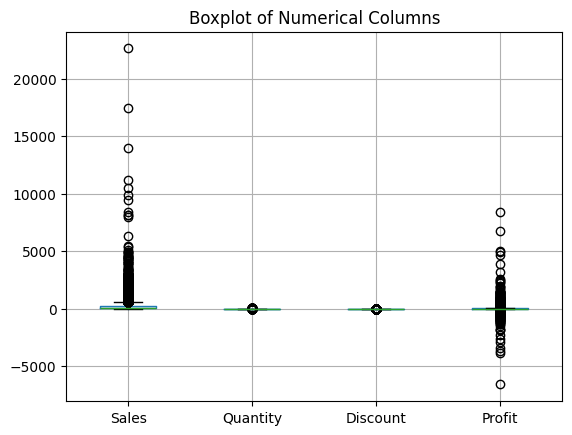

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

df[['Sales', 'Quantity', 'Discount', 'Profit']].boxplot()
plt.title('Boxplot of Numerical Columns')
plt.show()

In [17]:
df['Is Outlier'] = (
    (df['Sales'] > df['Sales'].quantile(0.99)) |
    (df['Quantity'] > df['Quantity'].quantile(0.99)) |
    (df['Discount'] > df['Discount'].quantile(0.99)) |
    (df['Profit'] > df['Profit'].quantile(0.99))
)
print(f"Number of outliers: {df['Is Outlier'].sum()}")

Number of outliers: 155


Drop Customer Name and Country columns.

In [18]:
df.drop(columns=['Customer Name', 'Country'], inplace=True)

In [19]:
df.info()
df.describe()
df.nunique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7484 entries, 0 to 7483
Data columns (total 25 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Row ID        7484 non-null   int64         
 1   Order ID      7484 non-null   object        
 2   Order Date    7484 non-null   datetime64[ns]
 3   Ship Date     7484 non-null   datetime64[ns]
 4   Ship Mode     7484 non-null   category      
 5   Customer ID   7484 non-null   object        
 6   Segment       7484 non-null   category      
 7   City          7484 non-null   object        
 8   State         7484 non-null   object        
 9   Postal Code   7484 non-null   int64         
 10  Region        7484 non-null   category      
 11  Product ID    7484 non-null   object        
 12  Category      7484 non-null   category      
 13  Sub-Category  7484 non-null   category      
 14  Product Name  7484 non-null   object        
 15  Sales         7484 non-null   float64 

Row ID          7484
Order ID        4254
Order Date      1191
Ship Date       1287
Ship Mode          4
Customer ID      791
Segment            3
City             501
State             49
Postal Code      598
Region             4
Product ID      1416
Category           3
Sub-Category      17
Product Name    1389
Sales           4430
Quantity          14
Discount          12
Profit          5376
Order Year         4
Order Month       12
Ship Year          5
Ship Month        12
Revenue         4430
Is Outlier         2
dtype: int64

In [ ]:
df.to_csv('../data/cleaned_superstore.csv', index=False)

: 